<a href="https://colab.research.google.com/github/neohack22/ebw3nt/blob/main/Mesure/Correction_Metriques_TP_supervise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelisation
## Session Lab : Introduction à l'apprentissage supervisé

## 1. Utilisation de ScikitLearn avec Python 3

*Cette séance pratique a un double but :*
1. *vous familiariser avec les librairies de calcul scientifique, de gestion de données et de Machine Learning sous Python*
2. *vous faire manipuler quelques techniques d'évaluation*



---


##Quelques références utiles :

1. [Documentation NumPy](https://docs.scipy.org/doc/numpy/user/index.html)
2. [Documentation SciPy](https://docs.scipy.org/doc/scipy/reference/)
3. [Documentation MatPlotLib](http://matplotlib.org/)
4. [Site scikit-learn](http://scikit-learn.org/stable/index.html)
5. [Site langage python](https://www.python.org/)


Nous importons d’abord les librairies utiles :

importe les bibliothèques Python essentielles pour l'analyse de données et la visualisation : numpy, matplotlib.pyplot

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

## 2. Expériences de reconnaissance de chiffres manuscrits

###2.1 Chargement de la base de données MNIST
Pour nos premières expériences, nous allons utiliser la base de données MNIST qui comporte les descriptions de chiffres manuscrits en format 28 x 28, soit 784 pixels, et les étiquettes associées. La base contient en tout 70 000 exemples, c’est-à-dire 7000 exemples de chaque chiffre.

Nous chargeons d’abord la base, puis nous examinons l’un des exemples qu’elle contient.

charger le célèbre ensemble de données MNIST, qui contient des images de chiffres manuscrits

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', cache=False)

importe la fonction fetch_openml de la bibliothèque sklearn.datasets pour télécharger l'ensemble de données MNIST, spécifiquement la version mnist_784.

In [ ]:
from sklearn.datasets import fetch_openml

# ValueError: No active dataset mnist_748 found.
# mnist = fetch_openml('mnist_748', cache=False)

mnist = fetch_openml('mnist_784', cache=False)

In [ ]:
mnist

{'DESCR': "**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered i

In [ ]:
X, y = mnist["data"], mnist ["target"]

extrait les caractéristiques (images des chiffres) de l'objet mnist et les affecte à la variable X ainsi que les étiquettes (les chiffres correspondants) et les affecte à la variable y

In [ ]:
X.shape

(70000, 784)

In [ ]:
X.shape

(70000, 784)

In [ ]:
y.shape

(70000,)

In [ ]:
y.shape

(70000,)

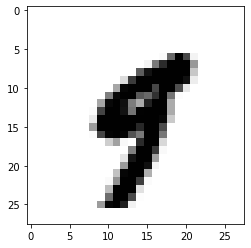

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
some_digit = X[36000]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap=matplotlib.cm.binary,interpolation="nearest")

sélectionne le 36 000ème exemple d'image de l'ensemble de données X et l'assigne à la variable some_digit. Les images MNIST sont stockées sous forme de tableaux unidimensionnels de 784 pixels. Cette ligne remodèle ce tableau unidimensionnel en un tableau bidimensionnel de 28x28 pixels.

### 2.2 Premier apprentissage
Nous sélectionnons 60 000 exemples pour l’apprentissage et 10 000 pour le test (la base MNIST est organisée de cette manière).

Pour les tests à venir, il est important de garantir que les exemples sont aléatoirement répartis dans la base d’apprentissage afin que tout tirage d’un sous-ensemble comporte à peu près la même proportion de chaque chiffre.

In [ ]:
X_train , X_test , y_train , y_test = X[:60000] , X[60000:] , y [:60000] , y [60000:]

divise les ensembles de données de caractéristiques (X) et d'étiquettes (y) en ensembles d'entraînement et de test. Plus précisément :

X_train : Contient les 60 000 premières images de l'ensemble de données X, destinées à l'entraînement du modèle.
X_test : Contient les images restantes de X (à partir de l'index 60 000 jusqu'à la fin), destinées à tester le modèle.
y_train : Contient les 60 000 premières étiquettes de l'ensemble de données y, correspondant à X_train.
y_test : Contient les étiquettes restantes de y (à partir de l'index 60 000 jusqu'à la fin), correspondant à X_test.

In [ ]:
shuffle_index = np.random.permutation(60000)

génère un tableau aléatoire d'indices de 0 à 59 999 (pour les 60 000 exemples d'entraînement).

In [ ]:
X_train , y_train = X_train[shuffle_index], y_train[shuffle_index]

utilise les shuffle_index générés précédemment pour réorganiser aléatoirement les ensembles de données d'entraînement X_train et y_train. En appliquant les mêmes indices de mélange aux deux ensembles, on s'assure que chaque image reste associée à son étiquette correcte après le brassage.



Nous allons d’abord apprendre des classifieurs binaires, à deux classes. Ici, nous choisissons
d’entraîner un classifieur à apprendre à reconnaître les 5 contre tous les autres chiffres.



In [ ]:
y_train = np.array(list(map(int,y_train)))
y_test=np.array(list(map(int,y_test)))

convertit les labels d'entraînement (y_train) et de test (y_test) en tableaux NumPy d'entiers.

In [ ]:
y_train_5 = ( y_train == 5)
y_test_5=(y_test==5)

Crée deux tableaux booléens, y_train_5 et y_test_5. Pour chaque élément dans y_train et y_test (qui sont les étiquettes des chiffres), vérifie si la valeur est égale à 5. Si c'est le cas, la valeur correspondante dans le nouveau tableau booléen sera True ; sinon, elle sera False.

In [ ]:
sum(y_train_5)

5421

Nous avons chargé un classifieur linéaire binaire avec descente de gradient stochastique.

Ici, par défaut, l’apprentissage s’arrête après 1000 itérations maximum ou bien quand la progression de l’erreur d’apprentissage d’une itération à la suivante vaut moins que $10^{-3}$.
Voir l’url :
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
pour les détails du paramétrage de cette fonction.

Nous entrainons ensuite le classifieur sur les données d’apprentissage, et nous le testons sur
l’exemple de 9 déjà vu (some_digit).

Après l'importation, créez une instance de ce classifieur. Il est très important de définir le paramètre random_state à une valeur fixe (par exemple, 42). Cela garantit que chaque fois que vous exécutez ce code, le processus d'initialisation aléatoire est le même, rendant ainsi vos résultats reproductibles.<br>
Utilisez la méthode .fit() de votre objet sgd_clf pour l'entraîner. Vous lui passerez les caractéristiques d'entraînement (X_train) et les étiquettes cibles correspondantes (y_train_5, qui indiquent si l'image est un '5' ou non).

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=None, penalty='l2',
              power_t=0.5, random_state=42, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

C'est ici que le modèle "apprend" des données. Il ajuste ses paramètres internes pour minimiser les erreurs de prédiction sur X_train en fonction des vraies étiquettes y_train_5.

### Évaluation des performances

La méthode laplus simple est de calculer l'accuracy du modèle

In [ ]:
sgd_clf.predict([some_digit] )


array([False])

Une méthode courante d’évaluation d’un apprentissage supervisé de concept est la validation
croisée. Ici, nous utilisons une validation croisée à trois folds. Une valeur courante est 10 folds.
La fonction *cross_val_score* calcule les erreurs associées à chaque pli. Vous pouvez ensuite en
calculer la moyenne.

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.9691, 0.9518, 0.955 ])

Utilise la fonction cross_val_score de Scikit-learn pour évaluer la performance de votre classifieur sgd_clf en utilisant une méthode de validation croisée.<br>
Indique que la métrique d'évaluation à utiliser est l'"accuracy" (précision), c'est-à-dire le pourcentage de prédictions correctes.

Ces taux de bonne prédiction paraissent tout à fait impressionnants pour un apprentissage par
une méthode linéaire.

_Mais que ferait un classifieur qui se contenterait de toujours prédire not 5 ?_

Définit une classe personnalisée nommée Never5Classifier, qui hérite de BaseEstimator de Scikit-learn.<br>
Ce classifieur n'apprend rien des données d'entraînement. Quel que soit l'input, il ne modifie pas son comportement.<br>
Pour tout ensemble de données X qu'on lui donne, elle retourne un tableau NumPy de la même longueur que X, rempli de False (ou 0). Cela simule un classifieur qui ne prédit jamais le chiffre '5', quelle que soit l'image d'entrée.

In [ ]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
  def fit(self,X, y=None):
    pass

  def predict(self, X):
    return np.zeros((len(X),1), dtype=bool)

In [ ]:
never_5_clf = Never5Classifier()
y_train_pred=cross_val_score(never_5_clf, X_train, y_train_5 , cv=3, scoring="accuracy")
y_train_pred

array([0.9111 , 0.91095, 0.9069 ])

*Pas* très étonnant. Mais cela relativise la performance apparemment excellente du classifieur
linéaire !

En effet l'objectif de ce classifieur Never5Classifier est de servir de ligne de base ou de référence naïve. En évaluant sa performance, nous pouvons mieux comprendre si notre SGDClassifier fait réellement mieux que de simplement deviner (ou, dans ce cas, de toujours ne pas deviner le '5'). Si 90% des chiffres ne sont pas des '5', alors un classifieur qui dit toujours 'non-5' aura une précision de 90%, ce qui peut paraître élevé mais est en réalité trivial.

###Matrice de confusion

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,X_train , y_train_5 , cv=3)

Importe la fonction confusion_matrix depuis le module `sklearn.metrics`. `confusion_matrix` sert à évaluer la performance d’un modèle de classification en comparant les valeurs réelles (vraies classes) et les valeurs prédites par le modèle.<br>
Calcule la matrice de confusion entre :
*   `y_train_5` : les vraies labels de votre jeu d’entraînement (par exemple, “est-ce que l’image représente le chiffre 5 ou pas ?”).
*   `y_train_pred` : les prédictions faites par votre modèle pour ce même jeu d’entraînement.

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_train_5, y_train_pred)
cm

array([[53891,   688],
       [ 1469,  3952]])

```cpp
[[54000,  500],  # 54000 images correctement classées comme "pas-5", 500 images mal classées comme "5"
 [  400,  5000]] # 400 images mal classées comme "pas-5", 5000 correctement classées comme "5"```
 Cette matrice permet de voir où le modèle se trompe le plus, et pas seulement son taux de précision global.

Puis celle que l’on obtiendrait avec un classifieur parfait (qui prédit la classe donnée par la base
d’exemples).

In [ ]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

###Précision et rappel

In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
precision_score(y_train_5, y_train_pred)

0.7445498419038109

`precision_score(y_train_5, y_train_pred)` est une fonction utilisée en machine learning pour mesurer la **précision** d’un modèle de classification.

Voici ce que ça signifie :

1. **y_train_5** : ce sont les **valeurs réelles** (les vrais labels) de ton jeu d’entraînement pour une tâche de classification (par exemple, savoir si un chiffre est un 5 ou pas).

2. **y_train_pred** : ce sont les **prédictions** faites par ton modèle sur ces mêmes données.

3. **precision_score** : c’est une métrique qui répond à la question :

> Parmi tous les exemples que le modèle a **prédit comme positifs**, combien étaient réellement positifs ?

Autrement dit, **la précision mesure la fiabilité des prédictions positives**.

* **Vrais Positifs (VP)** : le modèle a prédit « 5 » et c’était vraiment un 5.
* **Faux Positifs (FP)** : le modèle a prédit « 5 » mais ce n’était pas un 5.

**Exemple concret :**

* Si ton modèle prédit 100 fois « 5 » et que 90 fois c’est correct, alors :
  Précision = 90 / 100 = 0,9
  

Donc la précision = 0,9 (ou 90%), ce qui signifie que les prédictions positives sont correctes dans 90% des cas.

In [ ]:
recall_score(y_train_5, y_train_pred)

0.8253089835823649

$$Recall = \frac{True \ Positives}{True \ Positives + False \ Negatives}$$

Où :
*   **True Positives (TP)** : sont les instances positives que le modèle a correctement prédites comme positives.
*   **False Negatives (FN)** : sont les instances positives que le modèle a incorrectement prédites comme négatives (le modèle les a "manquées").

`recall_score(y_train_5, y_train_pred)` calcule le **rappel** d’un modèle de classification :

---
Il mesure la capacité du modèle à **identifier correctement tous les exemples positifs**.


* **TP (True Positives)** : exemples positifs correctement identifiés comme positifs.
* **FN (False Negatives)** : exemples positifs que le modèle a **manqués** et classés comme négatifs.

En d’autres termes : le rappel répond à la question **« parmi tous les vrais positifs, combien le modèle a-t-il trouvés ? »**

---

Supposons que tu essayes de détecter le chiffre 5 ici :

| Vérité | Prédiction |      |
| ------ | ---------- | ---- |
| 5      | 5          | ✅ TP |
| 5      | 3          | ❌ FN |
| 3      | 5          | ❌ FP |
| 3      | 3          | ✅ TN |

* TP = 1
* FN = 1

Le rappel serait donc **0,5**, ce qui signifie que ton modèle a trouvé **50 % des vrais 5**.

In [ ]:
from sklearn.metrics import f1_score

Le **F1-score** est une **moyenne harmonique** de la précision et du rappel. Il combine les deux mesures en une seule valeur pour donner un aperçu global de la performance du modèle :

* Le F1-score varie de 0 à 1.
* Plus il est proche de 1, mieux le modèle équilibre précision et rappel.
* Il est particulièrement utile lorsque **faux positifs et faux négatifs ont un coût différent**, ou quand les classes sont déséquilibrées.

**Astuce mnémotechnique :** si tu veux un modèle qui ne rate pas de vrais positifs mais ne veut pas trop se tromper non plus, regarde le F1-score plutôt que juste la précision ou le rappel.

In [ ]:
f1_score(y_train_5,y_train_pred)

0.7828521434820647

### Le compromis précision vs. rappel

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])

`decision_function` est une méthode qui ne renvoie pas directement la prédiction finale (comme predict le ferait).
Elle renvoie plutôt un score pour chaque classe, appelé score de décision.
Plus le score est grand pour une classe donnée, plus le modèle est “confiant” que l’entrée appartient à cette classe.

In [ ]:
y_scores

array([-5652.38188902])

Cette ligne transforme des **probabilités en prédictions binaires** (oui/non) en fonction d’un seuil choisi :

1. **`y_scores`** :
   C’est généralement un tableau (ou une série) de **scores ou probabilités** que certains échantillons appartiennent à une classe particulière. Par exemple, si tu entraînes un modèle pour reconnaître des chiffres, `y_scores[i]` pourrait être la probabilité que le chiffre de l’image i soit un certain chiffre, par exemple le 5.

2. **`threshold`** :
   C’est une **valeur seuil** choisie pour décider à partir de quelle probabilité on considère que l’échantillon appartient à la classe. Par exemple, si `threshold = 0.5`, on considère que si la probabilité est supérieure à 0.5, le modèle prédit la présence de la classe.

3. **`y_scores > threshold`** :
   Cette comparaison **retourne un tableau de valeurs booléennes** (True ou False).

   * True si le score dépasse le seuil → le modèle prédit que l’échantillon appartient à la classe.
   * False sinon → le modèle prédit que l’échantillon n’appartient pas à la classe.

4. **`y_some_digit_pred = ...`** :
   On stocke le résultat (tableau de True/False) dans `y_some_digit_pred`.
   Cela représente donc les **prédictions finales** après avoir appliqué le seuil sur les scores.

In [ ]:
threshold = 0

In [ ]:
y_some_digit_pred =(y_scores> threshold)

In [ ]:
threshold = 210000

In [ ]:
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
y_scores=cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

Par défaut, `cross_val_predic` renvoie les classes prédites (0 ou 1).
En ajoutant `method="decision_function"`, elle renvoie les scores bruts du modèle avant la conversion en classes.
Ces scores sont utiles pour tracer des courbes ROC, precision-recall, ou ajuster le seuil de décision.

In [ ]:
from sklearn.metrics import precision_recall_curve

`precision_recall_curve est utilisé pour évaluer un modèle de classification binaire, surtout quand les classes sont déséquilibrées (par exemple, peu de frauduleux vs beaucoup de transactions normales).

In [ ]:
y_scores.shape

(60000,)

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

`precisions, recalls, thresholds = precision_recall_curve()
` sert à calculer les courbes **précision-rappel** pour un modèle de classification :
**`precision_recall_curve`** calcule **tous les couples précision-rappel possibles** en faisant varier le seuil de décision.

Pour chaque seuil :

   * **Précision** = proportion de prédictions positives correctes parmi toutes les prédictions positives.
   * **Rappel (ou sensibilité)** = proportion de vrais positifs détectés parmi tous les positifs réels.

**Ce que renvoie la fonction** :

   * `precisions` : un tableau avec les valeurs de précision pour chaque seuil.
   * `recalls` : un tableau avec les valeurs de rappel correspondantes.
   * `thresholds` : les valeurs de seuil utilisées pour générer les couples précision-rappel.

In [ ]:
def plot_precision_recall_vs_thresholds(precisions, recalls,thresholds):
  plt.plot(thresholds, precisions[:-1],"b--", label="Precision",linewidth=2)
  plt.plot(thresholds, recalls[:-1],"g--", label="Recall",linewidth=2)
  plt.xlabel("Threshold",fontsize =16)
  plt.legend(loc="upper left",fontsize=16)
  plt.ylim([0,1])

Cette fonction permet de visualiser comment la **précision** et le **rappel** changent lorsque tu varies le **seuil de classification**. C’est très utile pour choisir un seuil optimal selon que tu privilégies la précision ou le rappel :

Cette fonction trace **la précision et le rappel en fonction des seuils** pour un modèle de classification binaire.

---

**Tracé de la précision :**

```python
plt.plot(thresholds, precisions[:-1],"b--", label="Precision", linewidth=2)
```

* `precisions[:-1]` : on enlève le dernier élément de `precisions` car il y a souvent un élément de plus que le nombre de seuils.
* `"b--"` : ligne bleue en pointillés.
* `label="Precision"` : nom de la courbe dans la légende.
* `linewidth=2` : épaisseur de la ligne.

---

**Tracé du rappel :**

```python
plt.plot(thresholds, recalls[:-1],"g--", label="Recall", linewidth=2)
```

* `recalls[:-1]` : même principe que pour la précision.
* `"g--"` : ligne verte en pointillés.
* `label="Recall"` : nom de la courbe dans la légende.

---

**Ajout des labels et légende :**

```python
plt.xlabel("Threshold", fontsize=16)
plt.legend(loc="upper left", fontsize=16)
```

* `xlabel` : étiquette de l’axe X (ici les seuils).
* `legend` : ajoute la légende en haut à gauche avec une taille de texte de 16.

---

**Limite de l’axe Y :**

```python
plt.ylim([0,1])
```

L’axe des ordonnées (précision/rappel) est limité entre 0 et 1, puisque ces valeurs sont des proportions.

In [ ]:
plt.figure(figsize=(8,4))

In [ ]:
plt.figure(figsize=(8,4))

<Figure size 576x288 with 0 Axes>

<Figure size 576x288 with 0 Axes>

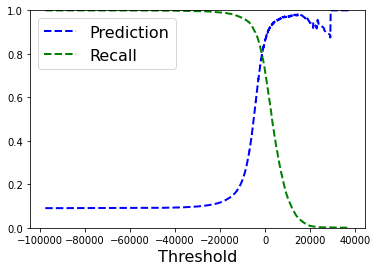

In [ ]:
plot_precision_recall_vs_thresholds(precisions, recalls,thresholds)

Il est également intéressant de tracer la figure précision en fonction du rappel !

### Courbe ROC

In [ ]:
from sklearn.metrics import roc_auc_score

# y_train_5 contient les vraies étiquettes (True si c'est un '5', False sinon)
# y_scores contient les scores de décision du SGDClassifier pour la classe '5'

auc_score = roc_auc_score(y_train_5, y_scores)
print(f"L'AUC ROC de votre classifieur est : {auc_score:.4f}")

Un AUC ROC d'environ **0.96** est généralement considéré comme un très bon score, indiquant que votre modèle est capable de bien séparer les exemples positifs (les '5') des exemples négatifs (les non-'5').

In [ ]:
my_y_scores = y_scores

In [ ]:
from sklearn.metrics import roc_curve

`roc_curve` est une fonction utilisée pour **évaluer les performances d’un modèle de classification binaire**. Elle sert à tracer la **courbe ROC (Receiver Operating Characteristic)**. Cette courbe montre le compromis entre deux métriques :

1. **True Positive Rate / Sensibilité / Recall** : la proportion de vrais positifs correctement identifiés.

2. **False Positive Rate** : la proportion de négatifs incorrectement classés comme positifs.

---


```python
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
```

* **`y_true`** : les vraies étiquettes (0 ou 1).
* **`y_scores`** : les probabilités de prédiction pour la classe positive (souvent issues de `model.predict_proba(X)[:, 1]`).
* **`fpr`**, **`tpr`** : listes des taux FPR et TPR pour différents seuils.
* **`thresholds`** : les valeurs de seuil utilisées pour calculer chaque point sur la courbe.

In [ ]:
fpr,tpr,thresholds = roc_curve(y_train_5,my_y_scores)

In [ ]:
def plot_roc_curve(fpr,tpr,label=None):
  plt.plot(fpr,tpr,linewidth=2,label=label)
  plt.plot([0,1],[0,1],'k--')
  plt.axis([0,1,0,1])
  plt.xlabel('FPR',fontsize=16)
  plt.ylabel('TPR',fontsize=16)

In [ ]:
plt.figure(figsize=(8,4))

<Figure size 576x288 with 0 Axes>

<Figure size 576x288 with 0 Axes>

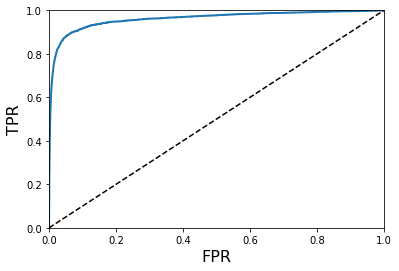

In [ ]:
plot_roc_curve(fpr,tpr)

### 1️⃣ La forme de la courbe

* La courbe **plus proche du coin supérieur gauche** = meilleur modèle.

  * Ici, TPR est élevé (beaucoup de vrais positifs détectés) et FPR est faible (peu de faux positifs).
* La diagonale (`y = x`) = modèle aléatoire.

  * Pas de capacité de discrimination entre classes positives et négatives.

Plus la courbe "monte vite" vers le haut puis "reste haute", plus le modèle est performant.

---

### 2️⃣ L’AUC (Area Under Curve)

* **AUC = 1** : modèle parfait
* **0,9 < AUC < 1** : très bon modèle
* **0,7 < AUC < 0,9** : modèle correct
* **0,5 < AUC < 0,7** : faible performance
* **AUC = 0,5** : modèle aléatoire

---

### 3️⃣ Choisir un seuil optimal

La ROC curve montre comment TPR et FPR changent selon le **seuil de classification**.

* Selon ton application, tu peux choisir un `threshold qui **maximise TPR** (sensible) ou qui **minimise FPR** (précis).
* Ex : dans un test médical, tu veux peut-être détecter tous les malades → privilégier TPR élevé, même si FPR augmente.

##Performance globale du prédicteur en multiclass



In [ ]:
sgd_clf.fit(X_train, y_train)
predictions=sgd_clf.predict(X_test)

In [ ]:
score=sgd_clf.score(X_test,y_test)

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.8727 , 0.85315, 0.85665])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train, cv=3)

## Matrice de confusion

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_train, y_train_pred)

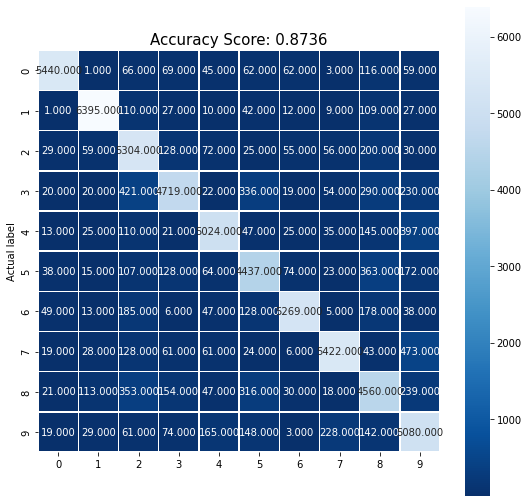

In [ ]:
import seaborn as sns

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);
plt.savefig('toy_Digits_ConfusionSeabornCodementor.png')
plt.show();

## Precision et rappel

In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
precision_score(y_train, y_train_pred,average='micro')

0.8608333333333333

`micro` : on additionne tout

`macro (autre option) : on calcule la précision par classe puis on fait la moyenne, ce qui peut donner un résultat différent.

In [ ]:
recall_score(y_train, y_train_pred,average='micro')

0.8608333333333333

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train,y_train,cv=3,method="decision_function")

##Exercice : regression logistique

Soit les données digits suivants, en utilisant la librairie scikitlearn, effectuer une regression logistique en suivant les étapes vues au dessus.

Appliquez différentes régularisations (ridge,lasso par exemple, voir documentation scikitlearn), et effectuer une recherche d'hyperparamètres: cf  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [ ]:
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits()

`load_digits est un jeu de données intégré qui contient des images de chiffres manuscrits (0 à 9) en 8x8 pixels.

C’est pratique pour s’entraîner avec des modèles de machine learning sur des petits ensembles de données

In [ ]:
# Print to show there are 1797 images (8 by 8 images for a dimensionality of 64)
print("Image Data Shape" , digits.data.shape)

# Print to show there are 1797 labels (integers from 0-9)
print("Label Data Shape", digits.target.shape)

Image Data Shape (1797, 64)
Label Data Shape (1797,)


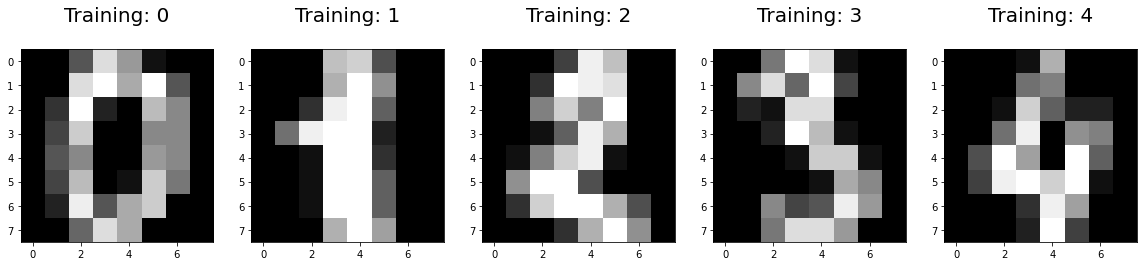

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
  plt.subplot(1, 5, index + 1)
  plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
  plt.title('Training: %i\n' % label, fontsize = 20)

`zip(digit.data[0:5], digits.target[0:5])` associe chaque image à son label, pour les 5 premières images.

`enumerate(...) permet de récupérer un index pour chaque image (0 à 4 ici).

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25, random_state=0)

### Les régularisations (`penalty`)

Quand tu entraînes un modèle, parfois il apprend **trop bien** les données d’entraînement (**surapprentissage**). La régularisation sert à **freiner le modèle**, pour qu’il généralise mieux sur de nouvelles données.

* **L2 (Ridge)** :

  * Pénalise les coefficients trop grands.
  * Tend à **réduire tous les coefficients un peu**, mais aucun n’est complètement zéro.
  * Bon si tu penses que toutes tes variables ont un rôle.

* **L1 (Lasso)** :

  * Pénalise aussi les coefficients mais peut **mettre certains coefficients exactement à zéro**.
  * Sert donc à **sélectionner automatiquement les variables importantes**.

* **ElasticNet** :

  * Mélange L1 et L2.
  * Sert quand tu veux à la fois **réduction et sélection de variables**.

La régularisation contrôle la complexité de ton modèle pour éviter qu’il « mémorise » juste les données d’entraînement.

---

### Pourquoi GridSearchCV est utile

* Chaque régularisation peut donner des performances **très différentes** selon tes données.
* `GridSearchCV` teste **toutes les combinaisons possibles** d’hyperparamètres (ici, juste le type de régularisation, mais ça peut être plein d’autres choses).
* Il choisit **automatiquement le paramètre qui donne les meilleurs résultats** sur une validation croisée.

Tu n’as pas à deviner quel type de régularisation est le mieux, le Grid Search s’en charge pour toi.

In [ ]:
#from sklearn import svm, datasets
#from sklearn.model_selection, import GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier

parameters = {'penalty': ['l2', 'l1','elasticnet']}

#GridSearchCV(estimator=SVC(),
SGDC = SGDClassifier()
GSCV = GridSearchCV(estimator=SGDC, # cf https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
             param_grid=parameters) # ridge est penalty l2 et lasso est l1
#sorted(clf.cv_results_.keys())


* `GridSearchCV` : C’est un outil pour trouver automatiquement les **meilleurs hyperparamètres** pour un modèle en testant toutes les combinaisons possibles.

---

### Hyperparamètres à tester

```python
parameters = {'penalty': ['l2', 'l1','elasticnet']}
```

* `penalty` : c’est la **régularisation** que l’on applique pour éviter le surapprentissage (overfitting).

  * `'l2'` → Ridge (pénalise la somme des carrés des coefficients)
  * `'l1'` → Lasso (pénalise la somme des valeurs absolues des coefficients, ce qui peut donner à certains coefficients la valeur zéro)
  * `'elasticnet'` → Combinaison de L1 et L2

---

### Grid Search

* `param_grid=parameters` : les paramètres que l’on veut tester
* `GridSearchCV` va **entraîner plusieurs modèles**, chacun avec un type de régularisation différent, et trouver celui qui donne la meilleure performance selon le score par défaut (accuracy pour un classifieur).